## Exploratory Data Analysis

In [7]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf

In [8]:
files = {
    "COIN": "COIN_5min_2yr.csv",
    "NVDA": "NVDA_5min_2yr.csv",
    "OKLO": "OKLO_5min_2yr.csv",
    "PLTR": "PLTR_5min_2yr.csv",
    "TSLA": "TSLA_5min_2yr.csv",
}

dfs = []
for sym, path in files.items():
    d = pd.read_csv(path, parse_dates=["timestamp"])
    d["symbol"] = sym
    dfs.append(d)

raw = pd.concat(dfs, ignore_index=True)

print("Combined shape:", raw.shape)
print("Symbols:", raw["symbol"].value_counts())
print(raw.head())

Combined shape: (401473, 9)
Symbols: symbol
NVDA    81536
TSLA    81536
PLTR    81523
COIN    81506
OKLO    75372
Name: count, dtype: int64
  symbol                 timestamp     open      high     low     close  \
0   COIN 2024-02-28 17:00:00+00:00  210.435  211.2000  208.38  211.2000   
1   COIN 2024-02-28 17:05:00+00:00  211.166  211.6300  210.38  210.8750   
2   COIN 2024-02-28 17:10:00+00:00  210.770  211.1950  209.25  211.0379   
3   COIN 2024-02-28 17:15:00+00:00  211.040  211.4599  207.80  207.8900   
4   COIN 2024-02-28 17:20:00+00:00  207.960  209.0000  206.50  206.7100   

     volume  trade_count        vwap  
0  434465.0       5272.0  209.858263  
1  238866.0       4011.0  211.133156  
2  258458.0       3356.0  210.383626  
3  296406.0       4428.0  209.852641  
4  334472.0       4715.0  207.499718  


In [9]:
# set variables

# I want only active trading hours 9:30 - 4PM Eastern Time
REGULAR_SESSION_ONLY = True
TZ_LOCAL = "America/New_York"

df = raw.copy()

# check timestamps
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
bad_ts = df["timestamp"].isna().sum()
if bad_ts:
    print("bad timestamps:", bad_ts)

# convert to eastern time
df["ts_ny"] = df["timestamp"].dt.tz_convert(TZ_LOCAL)

# sort by stock and timestamp
df = df.sort_values(["symbol", "timestamp"]).reset_index(drop=True)

# ensure we don't have duplicates
dup = df.duplicated(subset=["symbol", "timestamp"]).sum()
print("duplicate (symbol,timestamp):", dup)
if dup:
    df = df.drop_duplicates(subset=["symbol", "timestamp"], keep="last").reset_index(drop=True)

# filter for active trading hours 9:30 - 16:00
df["date_ny"] = df["ts_ny"].dt.date
df["time_ny"] = df["ts_ny"].dt.time

if REGULAR_SESSION_ONLY:
    mask = (df["ts_ny"].dt.hour > 9) | ((df["ts_ny"].dt.hour == 9) & (df["ts_ny"].dt.minute >= 30))
    mask &= (df["ts_ny"].dt.hour < 16)
    before = len(df)
    df = df.loc[mask].reset_index(drop=True)
    print(f"regular session rows kept: {len(df)} / {before}")

deltas = df.groupby("symbol")["timestamp"].diff().dropna()
vc = deltas.value_counts().head(8)
print("Top time deltas (per-symbol):")
print(vc)

print("min timestamp:", df["timestamp"].min())
print("max timestamp:", df["timestamp"].max())

for sym in sorted(df["symbol"].unique()):
    d = df[df["symbol"] == sym]
    print(f"\n{sym} head:")
    print(d.head(2)[["symbol","timestamp","ts_ny","open","high","low","close","volume"]])
    print(f"{sym} tail:")
    print(d.tail(2)[["symbol","timestamp","ts_ny","open","high","low","close","volume"]])

duplicate (symbol,timestamp): 0
regular session rows kept: 171812 / 401473
Top time deltas (per-symbol):
timestamp
0 days 00:05:00    169260
0 days 17:35:00      1692
2 days 17:35:00       387
0 days 00:10:00       149
0 days 00:15:00        75
1 days 17:35:00        49
3 days 17:35:00        42
0 days 00:20:00        26
Name: count, dtype: int64
min timestamp: 2024-02-28 16:50:00+00:00
max timestamp: 2026-02-27 16:55:00+00:00

COIN head:
  symbol                 timestamp                     ts_ny     open    high  \
0   COIN 2024-02-28 17:00:00+00:00 2024-02-28 12:00:00-05:00  210.435  211.20   
1   COIN 2024-02-28 17:05:00+00:00 2024-02-28 12:05:00-05:00  211.166  211.63   

      low    close    volume  
0  208.38  211.200  434465.0  
1  210.38  210.875  238866.0  
COIN tail:
      symbol                 timestamp                     ts_ny     open  \
35874   COIN 2026-02-27 16:50:00+00:00 2026-02-27 11:50:00-05:00  176.960   
35875   COIN 2026-02-27 16:55:00+00:00 2026-02-27 11:55

In [13]:
# check if we have all price action for each day by stock
day_coverage = (
    df.groupby(["symbol", "date_ny"])["ts_ny"]
      .agg(first="min", last="max", bars="count")
      .reset_index()
)

print(day_coverage.head(10))

# regular trading hours has about 78 5 minute candles

fullish = day_coverage["bars"] >= 75

print("\nFull trading days per symbol:")
print(day_coverage.groupby("symbol")["bars"].apply(lambda s: (s >= 75).sum()).sort_values(ascending=False))

print("\nTotal full trading day rows:", fullish.sum(), "out of", len(day_coverage))

  symbol     date_ny                     first                      last  bars
0   COIN  2024-02-28 2024-02-28 12:00:00-05:00 2024-02-28 15:55:00-05:00    48
1   COIN  2024-02-29 2024-02-29 09:30:00-05:00 2024-02-29 15:55:00-05:00    78
2   COIN  2024-03-01 2024-03-01 09:30:00-05:00 2024-03-01 15:55:00-05:00    78
3   COIN  2024-03-04 2024-03-04 09:30:00-05:00 2024-03-04 15:55:00-05:00    78
4   COIN  2024-03-05 2024-03-05 09:30:00-05:00 2024-03-05 15:55:00-05:00    78
5   COIN  2024-03-06 2024-03-06 09:30:00-05:00 2024-03-06 15:55:00-05:00    78
6   COIN  2024-03-07 2024-03-07 09:30:00-05:00 2024-03-07 15:55:00-05:00    78
7   COIN  2024-03-08 2024-03-08 09:30:00-05:00 2024-03-08 15:55:00-05:00    78
8   COIN  2024-03-11 2024-03-11 09:30:00-04:00 2024-03-11 15:55:00-04:00    78
9   COIN  2024-03-12 2024-03-12 09:30:00-04:00 2024-03-12 15:55:00-04:00    78

Full trading days per symbol:
symbol
COIN    453
OKLO    442
PLTR    423
NVDA    421
TSLA    420
Name: bars, dtype: int64

Total f

In [21]:
# function to plot 2 year price data as candle stick charts
def plot_daily(symbol, df):
    import pandas as pd
    import mplfinance as mpf

    d = df[df["symbol"] == symbol].copy()
    d["ts_ny"] = pd.to_datetime(d["ts_ny"])
    d = d.set_index("ts_ny").sort_index()

    daily = d.resample("1D").agg({
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum"
    }).dropna()

    mc = mpf.make_marketcolors(up="green", down="red", edge="inherit", wick="inherit", volume="inherit")
    style = mpf.make_mpf_style(marketcolors=mc, gridstyle="-")

    mpf.plot(
        daily, type="candle", volume=True, style=style,
        title=f"{symbol} — Daily Candles (from 5-min RTH)",
        ylabel="Price", ylabel_lower="Volume", figsize=(14, 7), tight_layout=True
    )

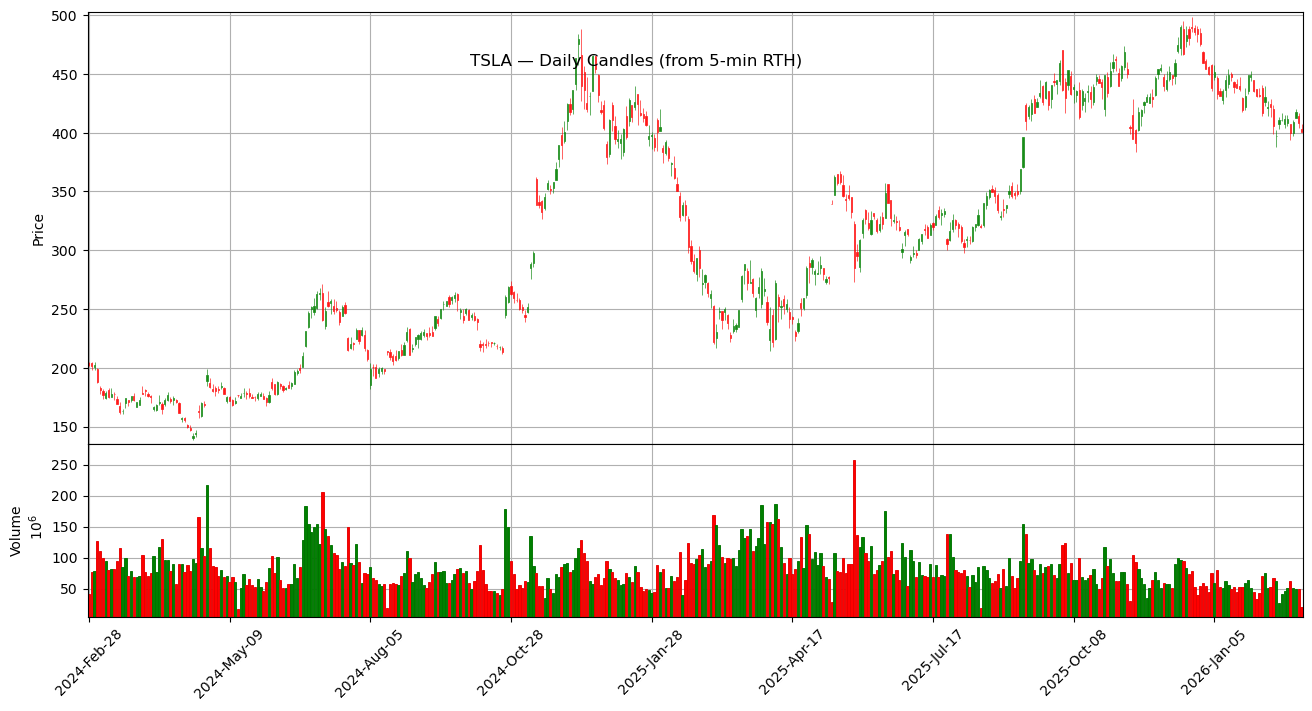

In [22]:
plot_daily("TSLA", df)

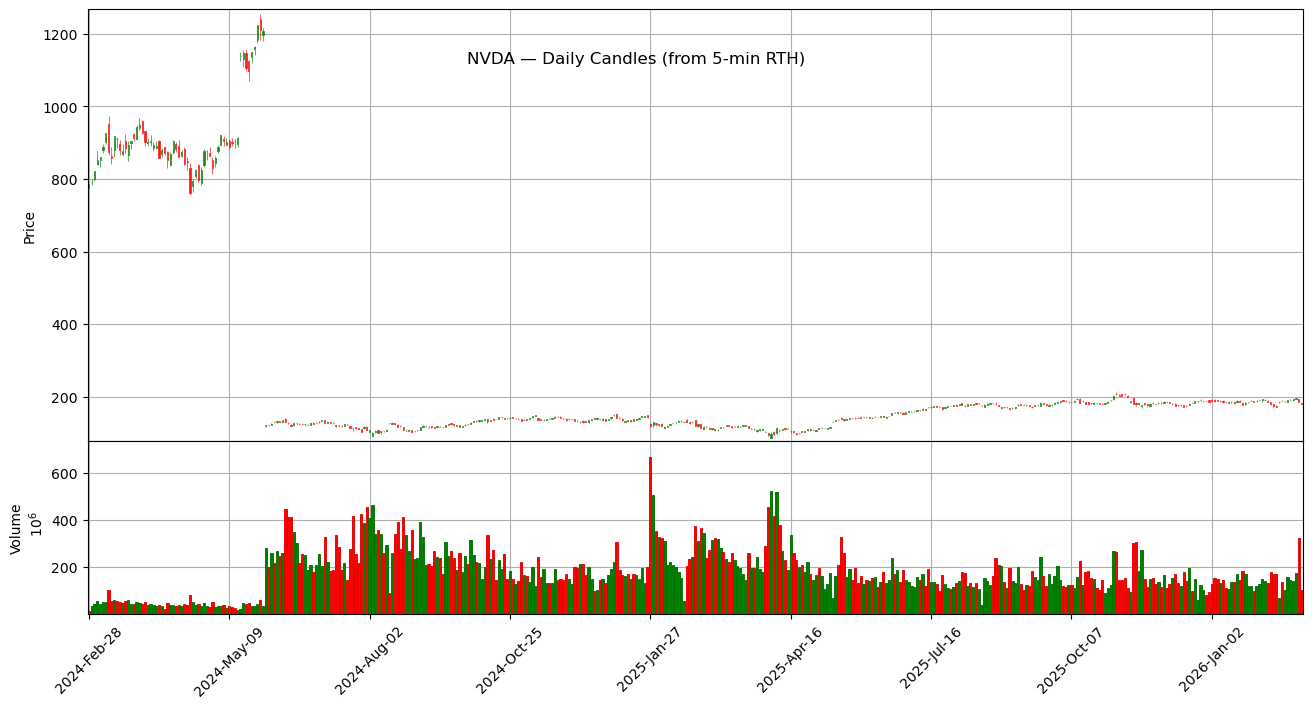

In [16]:
plot_daily("NVDA", df)

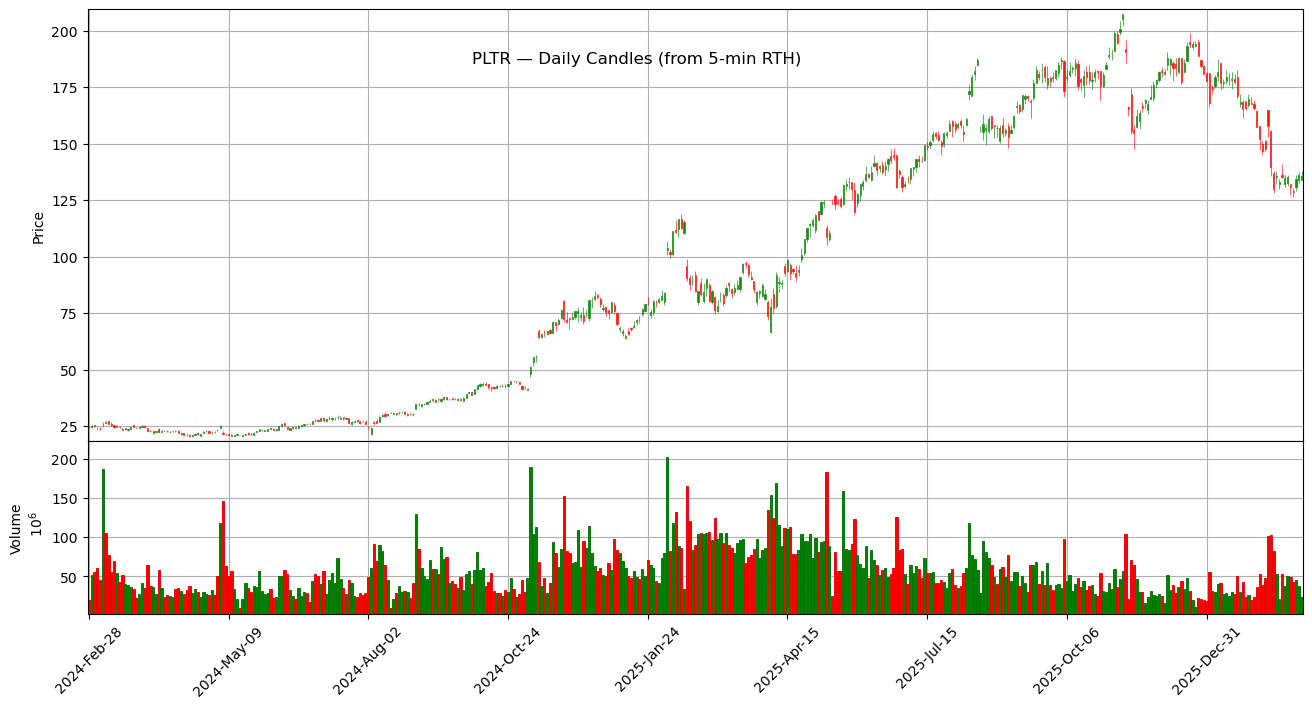

In [17]:
plot_daily("PLTR", df)

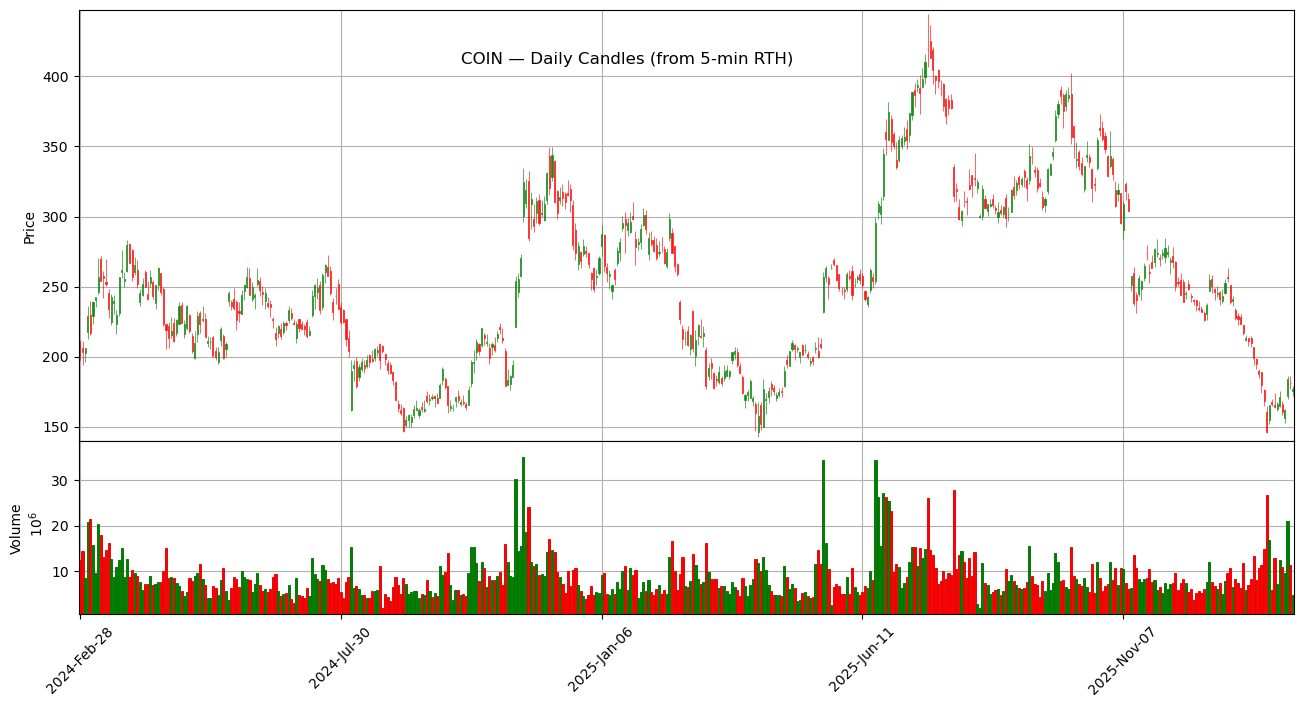

In [18]:
plot_daily("COIN", df)

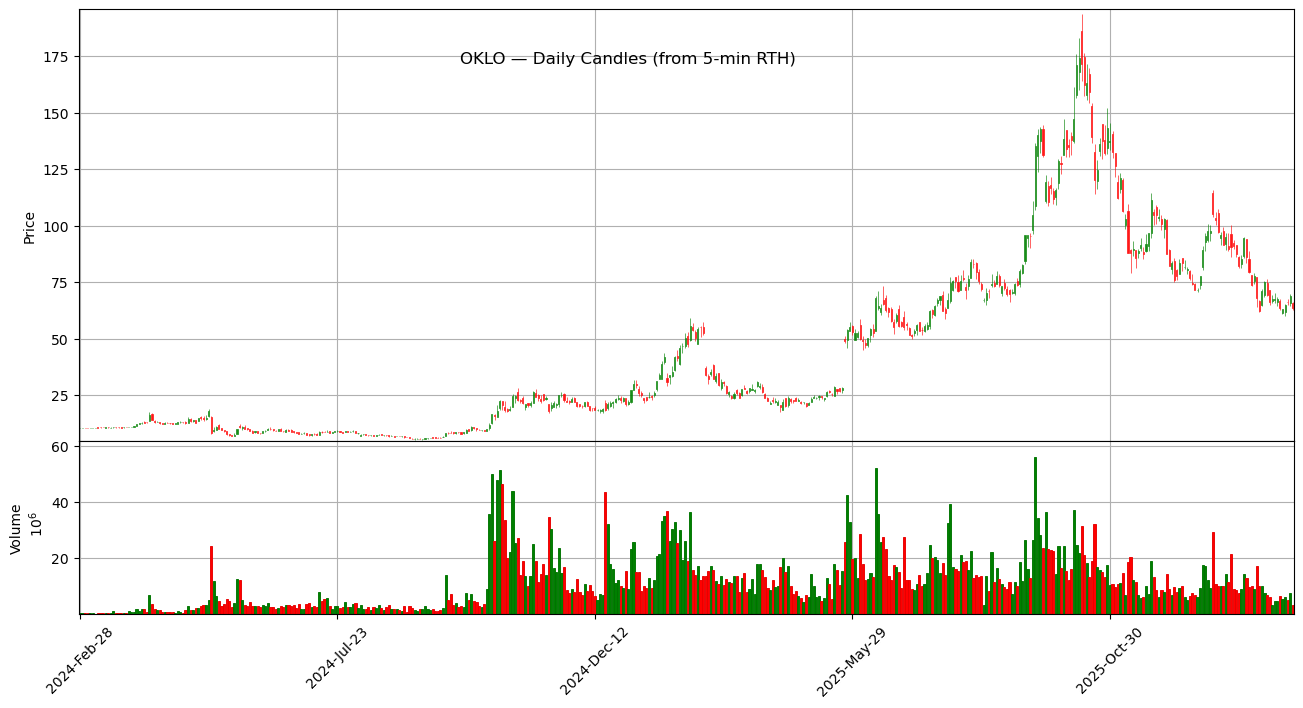

In [19]:
plot_daily("OKLO", df)

In [23]:
# save cleaned 5M RTH dataset

rth_cols = [
    "symbol","timestamp","ts_ny","date_ny",
    "open","high","low","close","volume","trade_count","vwap"
]

df_rth = df[rth_cols].copy()

df_rth.to_csv("multiasset_5m_rth_only.csv", index=False)

print("Saved: multiasset_5m_rth_only.csv")
print("Rows:", len(df_rth))
print("\nRows per symbol:")
print(df_rth["symbol"].value_counts())

Saved: multiasset_5m_rth_only.csv
Rows: 171812

Rows per symbol:
symbol
COIN    35876
OKLO    35782
PLTR    33489
NVDA    33355
TSLA    33310
Name: count, dtype: int64


## Feature Engineering

We will calculate price action indicators in preparation for generating entry and exits

The indicators we'll use are:
- VWAP
- ATR / Volatility
- Returns
- Range
- Volume Impulse
- Time of Day

In [24]:
# ensure price data is sorted by stock
df = df.sort_values(["symbol", "timestamp"]).reset_index(drop=True)

# calculate session VWAP
tp = (df["high"] + df["low"] + df["close"]) / 3.0
pv = tp * df["volume"]

df["vwap_session"] = (
    pv.groupby([df["symbol"], df["date_ny"]]).cumsum()
    / df["volume"].groupby([df["symbol"], df["date_ny"]]).cumsum()
)

# Average True Range (ATR)
prev_close = df.groupby("symbol")["close"].shift(1)

tr = pd.concat(
    [
        (df["high"] - df["low"]).abs(),
        (df["high"] - prev_close).abs(),
        (df["low"] - prev_close).abs(),
    ],
    axis=1,
).max(axis=1)

df["atr_14"] = tr.groupby(df["symbol"]).rolling(14, min_periods=14).mean().reset_index(level=0, drop=True)
df["atr_pct_14"] = df["atr_14"] / df["close"]

# 5 minute, 15 minute, 30 minute, 60 minute returns
df["ret_1"] = np.log(df["close"] / df.groupby("symbol")["close"].shift(1))
df["ret_3"] = np.log(df["close"] / df.groupby("symbol")["close"].shift(3))
df["ret_6"] = np.log(df["close"] / df.groupby("symbol")["close"].shift(6))
df["ret_12"] = np.log(df["close"] / df.groupby("symbol")["close"].shift(12))

# Range
df["range_pct"] = (df["high"] - df["low"]) / df["close"]
df["body_pct"] = (df["close"] - df["open"]).abs() / df["close"]
df["upper_wick_pct"] = (df["high"] - df[["open", "close"]].max(axis=1)) / df["close"]
df["lower_wick_pct"] = (df[["open", "close"]].min(axis=1) - df["low"]) / df["close"]

# VWAP distance
df["vwap_dist"] = (df["close"] - df["vwap_session"]) / df["close"]
df["vwap_dist_atr"] = (df["close"] - df["vwap_session"]) / df["atr_14"]

# Volume impulse
vol_ma20 = df.groupby("symbol")["volume"].rolling(20, min_periods=20).mean().reset_index(level=0, drop=True)
df["vol_ratio_20"] = df["volume"] / vol_ma20

# Realized volatility
df["rv_12"] = df.groupby("symbol")["ret_1"].rolling(12, min_periods=12).std().reset_index(level=0, drop=True)

# Time of Day
minutes = df["ts_ny"].dt.hour * 60 + df["ts_ny"].dt.minute
session_start = 9 * 60 + 30
x = (minutes - session_start) / 390.0
df["tod_sin"] = np.sin(2 * np.pi * x)
df["tod_cos"] = np.cos(2 * np.pi * x)

In [25]:
feature_cols = [
    "vwap_session","atr_14","atr_pct_14",
    "ret_1","ret_3","ret_6","ret_12",
    "range_pct","body_pct","upper_wick_pct","lower_wick_pct",
    "vwap_dist","vwap_dist_atr",
    "vol_ratio_20","rv_12",
    "tod_sin","tod_cos"
]

print("NaNs total:")
print(df[feature_cols].isna().sum().sort_values(ascending=False).head(12))

print("\nNaNs per symbol:")
print(df.groupby("symbol")[feature_cols].apply(lambda x: x.isna().sum()).head())

print("\nFeature preview:")
preview_cols = ["ts_ny","close","vwap_session","atr_14","vol_ratio_20","vwap_dist_atr","ret_1","ret_12"]
for sym in sorted(df["symbol"].unique()):
    print(f"\n {sym}")
    print(df[df["symbol"] == sym][preview_cols].tail(5))

NaNs total:
vol_ratio_20     95
vwap_dist_atr    65
atr_pct_14       65
atr_14           65
ret_12           60
rv_12            60
ret_6            30
ret_3            15
ret_1             5
vwap_session      0
tod_sin           0
body_pct          0
dtype: int64

NaNs per symbol:
        vwap_session  atr_14  atr_pct_14  ret_1  ret_3  ret_6  ret_12  \
symbol                                                                  
COIN               0      13          13      1      3      6      12   
NVDA               0      13          13      1      3      6      12   
OKLO               0      13          13      1      3      6      12   
PLTR               0      13          13      1      3      6      12   
TSLA               0      13          13      1      3      6      12   

        range_pct  body_pct  upper_wick_pct  lower_wick_pct  vwap_dist  \
symbol                                                                   
COIN            0         0               0              

Indicators with NaNs are expecting since they need rolling price data to be calculated

In [27]:
# save 5 minute RTH with features as csv
feature_cols = [
    "ret_1","ret_3","ret_6","ret_12",
    "atr_14","atr_pct_14",
    "vwap_session","vwap_dist","vwap_dist_atr",
    "vol_ratio_20",
    "range_pct","body_pct","upper_wick_pct","lower_wick_pct",
    "rv_12",
    "tod_sin","tod_cos"
]

base_cols = [
    "symbol","timestamp","ts_ny","date_ny",
    "open","high","low","close","volume","trade_count"
]

df_features = df[base_cols + feature_cols].copy()

# drop NaNs
df_regimes = df_features.dropna().reset_index(drop=True)

df_regimes.to_csv("multiasset_5m_rth_features.csv", index=False)

print("Saved: multiasset_5m_rth_features.csv")
print("Total rows:", len(df_regimes))

print("\nRows per symbol after dropna:")
print(df_regimes["symbol"].value_counts())

Saved: multiasset_5m_rth_features.csv
Total rows: 171717

Rows per symbol after dropna:
symbol
COIN    35857
OKLO    35763
PLTR    33470
NVDA    33336
TSLA    33291
Name: count, dtype: int64


### Entry Opportunities

We want to create entry signals based on a setup I used often (VWAP Reclaim)

Entry Signal:
- Long entry when price is below VWAP on the prior 5M bar and closes above VWAP on current bar
- We use volume as an indicator if price will continue to sustain upon reclaiming VWAP

In [29]:
# VWAP Reclaim setup signal

# We need volume and price to close above VWAP
VOL_IMPULSE = 1.5

prev_close = df.groupby("symbol")["close"].shift(1)
prev_vwap  = df.groupby("symbol")["vwap_session"].shift(1)

signal = (
    (prev_close < prev_vwap) &
    (df["close"] > df["vwap_session"]) &
    (df["vol_ratio_20"] >= VOL_IMPULSE) &
    (df["ret_1"] > 0)
)

signal_idx = np.flatnonzero(signal.values)

# enter on next 5min candle
entry_idx = signal_idx + 1
valid = (entry_idx < len(df)) & (df.loc[signal_idx, "symbol"].values == df.loc[entry_idx, "symbol"].values)

signal_idx = signal_idx[valid]
entry_idx  = entry_idx[valid]

entries = pd.DataFrame({
    "symbol": df.loc[signal_idx, "symbol"].values,
    "i_signal": signal_idx,
    "i_entry": entry_idx,
    "ts_signal": df.loc[signal_idx, "ts_ny"].values,
    "ts_entry": df.loc[entry_idx, "ts_ny"].values,
    "entry_price": df.loc[entry_idx, "open"].values,
})

needed_signal = ["atr_14", "vol_ratio_20", "vwap_session", "ret_1"]
needed_entry = ["atr_14"]

ok_signal = df.loc[entries["i_signal"], needed_signal].notna().all(axis=1).values
ok_entry  = df.loc[entries["i_entry"], needed_entry].notna().all(axis=1).values
entries = entries.loc[ok_signal & ok_entry].reset_index(drop=True)

print("Total entries found:", len(entries))
print("\nEntries by symbol:")
print(entries["symbol"].value_counts())

print("\nPreview:")
print(entries.head(5))

Total entries found: 1710

Entries by symbol:
symbol
OKLO    381
COIN    349
TSLA    336
PLTR    323
NVDA    321
Name: count, dtype: int64

Preview:
  symbol  i_signal  i_entry           ts_signal            ts_entry  \
0   COIN        48       49 2024-02-29 14:30:00 2024-02-29 14:35:00   
1   COIN       117      118 2024-02-29 20:15:00 2024-02-29 20:20:00   
2   COIN       283      284 2024-03-05 14:35:00 2024-03-05 14:40:00   
3   COIN       360      361 2024-03-06 14:30:00 2024-03-06 14:35:00   
4   COIN       578      579 2024-03-08 19:40:00 2024-03-08 19:45:00   

   entry_price  
0      209.720  
1      201.420  
2      233.650  
3      233.055  
4      257.810  


We have a good number of VWAP Reclaim setup opportunities between the 5 stocks.

### Trade Simulator and Labeling

We want to Identify these trades and label them for use later. We want to simulate multiple realistic parameter combinations for supervised learning targets. This will help the model learn how market conditions at entry influence execution settings.

We will evaluate 36 parameter combinations with varying stop sizes, target sizes, and max hold times. We'll simulate the trades and label for model use.

In [31]:
# stops, targets, and hold times
stops = [0.5, 0.75, 1.0]
targets = [0.75, 1.0, 1.5, 2.0]
holds = [3, 6, 12, 24] 

grid = [(s, t, h) for s in stops for t in targets for h in holds]
print("Grid size:", len(grid))

def simulate_one_entry_long(df, i_entry, stop_atr, target_atr, hold_bars):
    sym = df.at[i_entry, "symbol"]
    last_i = df[df["symbol"] == sym].index.max()

    entry_price = float(df.at[i_entry, "open"])
    atr = df.at[i_entry, "atr_14"]
    if pd.isna(atr) or atr <= 0:
        return None

    atr = float(atr)
    risk = stop_atr * atr
    stop_price = entry_price - risk
    target_price = entry_price + target_atr * atr
    i_end = min(i_entry + hold_bars - 1, last_i)
    window = df.loc[i_entry:i_end, ["high", "low", "close", "ts_ny"]]
    exit_price = float(window["close"].iloc[-1])
    exit_ts = window["ts_ny"].iloc[-1]
    reason = "TIME"

    for _, row in window.iterrows():
        lo = float(row["low"])
        hi = float(row["high"])

        if lo <= stop_price and hi >= target_price:
            exit_price = stop_price
            exit_ts = row["ts_ny"]
            reason = "STOP"
            break
        if lo <= stop_price:
            exit_price = stop_price
            exit_ts = row["ts_ny"]
            reason = "STOP"
            break
        if hi >= target_price:
            exit_price = target_price
            exit_ts = row["ts_ny"]
            reason = "TARGET"
            break

    R = (exit_price - entry_price) / risk
    return {
        "R": float(R),
        "exit_price": float(exit_price),
        "exit_ts": exit_ts,
        "exit_reason": reason,
        "stop_atr": float(stop_atr),
        "target_atr": float(target_atr),
        "hold_bars": int(hold_bars),
        "param_id": f"S{stop_atr}_T{target_atr}_H{hold_bars}",
    }

def best_params_for_entry(df, i_entry, grid):
    best = None
    for (s, t, h) in grid:
        out = simulate_one_entry_long(df, i_entry, s, t, h)
        if out is None:
            continue
        if (best is None) or (out["R"] > best["R"]):
            best = out
    return best

# label entries
labels = []
for row in entries.itertuples(index=False):
    i_entry = int(row.i_entry)
    best = best_params_for_entry(df, i_entry, grid)
    labels.append(best)

labels_df = pd.DataFrame(labels)
print("Labeled rows:", len(labels_df))

entries_labeled = pd.concat([entries.reset_index(drop=True), labels_df.reset_index(drop=True)], axis=1)

print(entries_labeled.head(10)[["symbol","ts_entry","entry_price","param_id","R","exit_reason","stop_atr","target_atr","hold_bars"]])
print("\nR summary:")
print(entries_labeled["R"].describe())

Grid size: 48
Labeled rows: 1710
  symbol            ts_entry  entry_price        param_id         R  \
0   COIN 2024-02-29 14:35:00      209.720   S1.0_T0.75_H3 -1.000000   
1   COIN 2024-02-29 20:20:00      201.420    S0.5_T2.0_H6  4.000000   
2   COIN 2024-03-05 14:40:00      233.650   S0.75_T2.0_H6  2.666667   
3   COIN 2024-03-06 14:35:00      233.055   S1.0_T0.75_H3 -1.000000   
4   COIN 2024-03-08 19:45:00      257.810   S0.5_T0.75_H3 -1.000000   
5   COIN 2024-03-11 13:30:00      270.010   S0.5_T0.75_H3 -1.000000   
6   COIN 2024-03-11 13:40:00      268.185   S0.5_T0.75_H3 -1.000000   
7   COIN 2024-03-13 14:00:00      257.790    S0.5_T2.0_H3  4.000000   
8   COIN 2024-03-14 13:40:00      241.460  S0.75_T0.75_H3  1.000000   
9   COIN 2024-03-20 13:55:00      233.500   S1.0_T2.0_H12  2.000000   

  exit_reason  stop_atr  target_atr  hold_bars  
0        STOP      1.00        0.75          3  
1      TARGET      0.50        2.00          6  
2      TARGET      0.75        2.00   

### Create Labeled dataset

This will include features, parameters, best R, and chronological data split

In [32]:
feature_cols = [
    "ret_1","ret_3","ret_6","ret_12",
    "atr_14","atr_pct_14",
    "vwap_session","vwap_dist","vwap_dist_atr",
    "vol_ratio_20",
    "range_pct","body_pct","upper_wick_pct","lower_wick_pct",
    "rv_12",
    "tod_sin","tod_cos"
]

idx = entries_labeled["i_signal"].astype(int).values
X = df.loc[idx, feature_cols].reset_index(drop=True)

# create dataset
final = pd.concat(
    [
        entries_labeled[["symbol","ts_signal","ts_entry","entry_price"]].reset_index(drop=True),
        X,
        entries_labeled[["param_id","R","exit_reason","exit_price","exit_ts","stop_atr","target_atr","hold_bars"]].reset_index(drop=True),
    ],
    axis=1,
)

final = final.rename(columns={
    "param_id": "best_param_id",
    "R": "best_R",
    "stop_atr": "best_stop_atr",
    "target_atr": "best_target_atr",
    "hold_bars": "best_hold_bars",
    "exit_reason": "best_exit_reason",
    "exit_price": "best_exit_price",
    "exit_ts": "best_exit_ts"
})

final["side"] = "LONG"

# split data 80/20 based on entry time
final = final.sort_values("ts_entry").reset_index(drop=True)
n = len(final)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)
final["split"] = "train"
final.loc[train_end:val_end, "split"] = "val"
final.loc[val_end:, "split"] = "test"

print("\nSplit counts:")
print(final["split"].value_counts())

print("\nTrain/Test date boundaries:")
print("Train max:", final.loc[final["split"]=="train","ts_entry"].max())
print("Val   max:", final.loc[final["split"]=="val","ts_entry"].max())
print("Test  min:", final.loc[final["split"]=="test","ts_entry"].min())

# save file
out_path = "multiasset_labeled_entries.csv"
final.to_csv(out_path, index=False)
print("\nSaved:", out_path)


Split counts:
split
train    1197
test      257
val       256
Name: count, dtype: int64

Train/Test date boundaries:
Train max: 2025-07-17 13:40:00
Val   max: 2025-10-29 18:50:00
Test  min: 2025-10-29 18:55:00

Saved: multiasset_labeled_entries.csv
